# Final Project
### Alphanumeric Number-Plate Reader (EMNIST-based)



## Problem framing

Meridian Access Systems runs gated parking at 34 sites; today's ticket
dispensers (~14,000 each) jam and cost ~8.50 per lost-ticket dispute. The
COO wants to know if plate recognition can replace tickets — the plate
becomes the account, gate opens on entry, billed on exit.

A misread isn't neutral: it bills the wrong customer. At 4,200 vehicles/day,
even 2% plate-level error ≈ 30,000 wrong bills/year. So the real question
isn't "how accurate can we get" — it's **which reads to trust automatically,
and which to route to a human.**

*This notebook is the team's working pipeline (spike → build → demo).*

## Spike

Before spending a full week building anything, we wanted to test the two
assumptions that would hurt the most if they turned out to be wrong. Our
course calls this a spike: a quick, throwaway test of a risky assumption,
done before committing real time to a plan that assumes the answer.

**The first assumption:** that a plate image can actually be split into one
piece per character. If that doesn't hold up, no amount of a good model
fixes it — recognition never even gets a fair shot at the problem.

**The second**: EMNIST has a well-known **orientation bug** where its raw images come out
**sideways** unless you catch it early, and we wanted to see exactly what that
looks like on a real example before it cost us a confused afternoon
mid-build.

Neither question needed a trained model or the real EMNIST download to
answer, so we tested both cheaply below, using a plate we made up ourselves.


In [4]:
import random, string
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from scipy import ndimage
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

FONT_PATH = fm.findfont(fm.FontProperties(family="monospace"))
print("Using font:", FONT_PATH)


Using font: /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf


## Part A  Where do the plate pictures come from?

We're not using real plates here — photographing someone else's plate
without their consent is a real privacy problem, not just a rule we're
following, so that was never really on the table. Instead we draw our own:
pick some letters and numbers, print them onto a plate-shaped image
ourselves. Because we're the ones choosing the text, we already know the
correct answer for every image we make — no labeling work, no limit on how
many we can generate, and we can make them as clean or as messy as we want
as the project goes on.

The cell below actually builds one of these and shows exactly what came
out, so what you're about to see is real output, not a preview.

Generated plate — ground-truth label: 'QAH2768'  (7 characters)


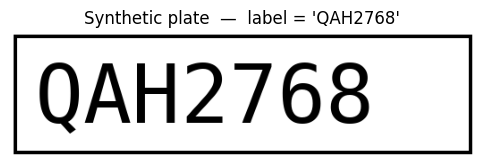

In [5]:
def make_plate(text=None, width=520, height=140, font_size=90, noise=0.0, seed=None):
    rng = random.Random(seed)
    if text is None:
        letters = ''.join(rng.choices(string.ascii_uppercase, k=3))
        digits = ''.join(rng.choices(string.digits, k=4))
        text = letters + digits
    img = Image.new("L", (width, height), color=255)
    draw = ImageDraw.Draw(img)
    font = ImageFont.truetype(FONT_PATH, font_size)
    draw.rectangle([4, 4, width - 4, height - 4], outline=0, width=4)
    draw.text((28, 18), text, fill=0, font=font)
    if noise > 0:
        arr = np.array(img).astype(np.float32)
        arr += np.random.normal(0, noise * 255, arr.shape)
        arr = np.clip(arr, 0, 255).astype(np.uint8)
        img = Image.fromarray(arr)
    return img, text

plate_img, plate_text = make_plate( seed=42)
print(f"Generated plate — ground-truth label: '{plate_text}'  ({len(plate_text)} characters)")

plt.figure(figsize=(6, 2))
plt.imshow(plate_img, cmap="gray")
plt.axis("off")
plt.title(f"Synthetic plate  —  label = '{plate_text}'")
plt.show()


## Part B — The segmentation spike

Before training anything, we needed to know: could we reliably split a
plate image into one blob per character? If not, character-level
classification — which is what EMNIST gives you — wouldn't help until that
was solved first.

The test: threshold the image (characters are dark, background is light),
label connected dark regions, and count how many distinct blobs survive
after throwing out tiny noise. Compare that count to the known ground truth
(`len(plate_text)`).

Ground truth: 7 characters  ->  segmentation found 7 blobs
MATCH — clean-plate segmentation works on this sample.


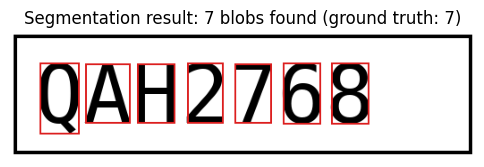

In [6]:
def segment_characters(img, dark_thresh=128, min_w=8, min_h=25):
    arr = np.array(img.convert("L"))
    binary = arr < dark_thresh
    # zero out the plate border so it isn't counted as a "character" blob
    binary[:8, :] = False
    binary[-8:, :] = False
    binary[:, :8] = False
    binary[:, -8:] = False
    labeled, _ = ndimage.label(binary)
    boxes = []
    for obj in ndimage.find_objects(labeled):
        h = obj[0].stop - obj[0].start
        w = obj[1].stop - obj[1].start
        if h >= min_h and w >= min_w:
            boxes.append(obj)
    boxes.sort(key=lambda o: o[1].start)  # left-to-right reading order
    return boxes

boxes = segment_characters(plate_img)
print(f"Ground truth: {len(plate_text)} characters  ->  segmentation found {len(boxes)} blobs")
if len(boxes) == len(plate_text):
    print("MATCH — clean-plate segmentation works on this sample.")
else:
    print("MISMATCH — segmentation over/under-split on this sample; thresholds need tuning.")

vis = plate_img.convert("RGB")
draw = ImageDraw.Draw(vis)
for obj in boxes:
    y0, y1 = obj[0].start, obj[0].stop
    x0, x1 = obj[1].start, obj[1].stop
    draw.rectangle([x0, y0, x1, y1], outline=(220, 30, 30), width=2)

plt.figure(figsize=(6, 2))
plt.imshow(vis)
plt.axis("off")
plt.title(f"Segmentation result: {len(boxes)} blobs found (ground truth: {len(plate_text)})")
plt.show()


Noisy plate — ground truth: 7 characters  ->  found 7 blobs


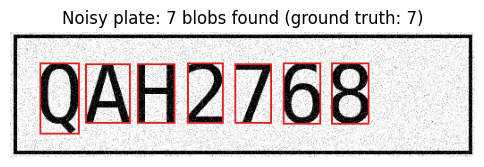

In [7]:
# Stress test: same plate, with noise added, to see where segmentation starts to break.
noisy_img, noisy_text = make_plate(seed=42, noise=0.12)
noisy_boxes = segment_characters(noisy_img)
print(f"Noisy plate — ground truth: {len(noisy_text)} characters  ->  found {len(noisy_boxes)} blobs")

vis2 = noisy_img.convert("RGB")
draw2 = ImageDraw.Draw(vis2)
for obj in noisy_boxes:
    y0, y1 = obj[0].start, obj[0].stop
    x0, x1 = obj[1].start, obj[1].stop
    draw2.rectangle([x0, y0, x1, y1], outline=(220, 30, 30), width=2)

plt.figure(figsize=(6, 2))
plt.imshow(vis2)
plt.axis("off")
plt.title(f"Noisy plate: {len(noisy_boxes)} blobs found (ground truth: {len(noisy_text)})")
plt.show()


Both plates matched here (even with noise added), segmentation still found
all 7 characters. That's reassuring, but it's only one noise level; it
doesn't tell us where segmentation actually starts to break, just that it
hadn't broken yet at this amount. The real open question is how much noise
a real plate photo might realistically have, and whether segmentation holds
up that far — that's still a decision we need to make, since segmentation
and recognition are two different failure points and this only rules out
one of them.

## Part C — What is the "EMNIST orientation bug," concretely?

It's been documented in GitHub issues for both PyTorch's torchvision and TensorFlow's
dataset libraries since at least 2019 (most recently reopened on torchvision
in December 2024). Common loaders unpack EMNIST's raw byte format in a way
that comes out rotated 90° and mirrored — a loader-level quirk, not a
mistake in the underlying data. If a loader reshapes the raw bytes the naive
way, every letter/digit comes out sideways instead of upright.

https://github.com/pytorch/vision/issues/8783


https://github.com/pytorch/pytorch/issues/42012


https://github.com/tensorflow/datasets/issues/812


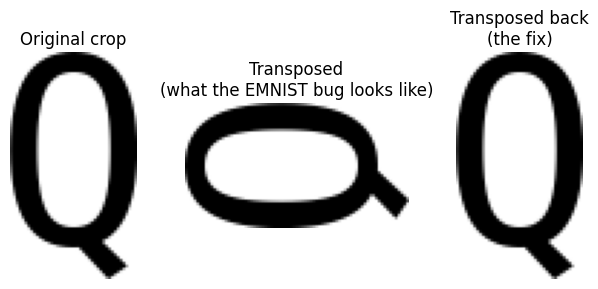

Fixed matches original exactly: True


In [8]:
# Grab one real character crop from the plate we already generated.
y0, y1 = boxes[0][0].start, boxes[0][0].stop
x0, x1 = boxes[0][1].start, boxes[0][1].stop
char_crop = np.array(plate_img)[y0:y1, x0:x1]

# Simulate the EMNIST transpose bug on this real crop.
buggy = char_crop.T  # this is the exact operation that goes wrong with EMNIST's raw format
fixed = buggy.T       # transposing back is the one-line fix

fig, axes = plt.subplots(1, 3, figsize=(7, 3))
axes[0].imshow(char_crop, cmap="gray"); axes[0].set_title("Original crop"); axes[0].axis("off")
axes[1].imshow(buggy, cmap="gray"); axes[1].set_title("Transposed\n(what the EMNIST bug looks like)"); axes[1].axis("off")
axes[2].imshow(fixed, cmap="gray"); axes[2].set_title("Transposed back\n(the fix)"); axes[2].axis("off")
plt.tight_layout()
plt.show()

print("Fixed matches original exactly:", np.array_equal(char_crop, fixed))


## Part D — Loading real EMNIST and checking for the bug

Now that the fix has been rehearsed on a character we already had, it's
time to check it against the real thing. This part downloads actual EMNIST
data (~535MB total across all splits, cached locally after the first run)
and checks the same orientation issue directly on it.

What "wrong" looks like: the label says one thing (e.g. digit 2) but the
raw image looks rotated/mirrored relative to a normal, upright 2. The fix:
transpose the image array (`.T`), same as before. The check below follows a
two-run pattern — the first run prints a hash and says there's no golden
value yet; once the "Fixed" panel is visually confirmed upright and
matching its label, that hash gets pasted into `KNOWN_GOOD_HASH` and the
cell is re-run. From then on, if the loader ever regresses, the check
catches it immediately instead of silently training on sideways characters.


100%|██████████| 562M/562M [00:05<00:00, 104MB/s]


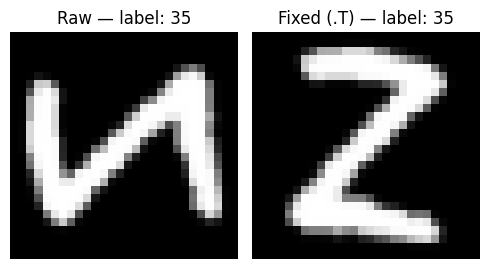

Sample label: 35
Hash of fixed image: 1b20baadb633d5260b83acc29e7a44a9cb08d8ee9c58f975e7ec2b5fdcb5fb7d


In [9]:
import hashlib
import numpy as np
import matplotlib.pyplot as plt

def load_emnist_sample(split="byclass", index=0, retries=1):
    """Downloads (if needed) and returns one raw EMNIST sample + its label.
    Retries once on failure since the NIST host is known to be flaky."""
    from torchvision import datasets
    last_err = None
    for attempt in range(retries + 1):
        try:
            ds = datasets.EMNIST(root="./data", split=split, train=True, download=True)
            img, label = ds[index]
            return np.array(img), label
        except Exception as e:
            last_err = e
            print(f"Attempt {attempt + 1} failed: {e}")
    raise RuntimeError(
        "Could not download EMNIST after retries. Fallback options: "
        "(1) manually download gzip.zip from the NIST EMNIST page and unzip "
        "into ./data/EMNIST/raw, or (2) `pip install emnist` and use "
        "emnist.extract_training_samples('byclass') instead of torchvision."
    ) from last_err


raw, label = load_emnist_sample(split="byclass", index=0)
fixed = raw.T  # the fix established in Part C

fig, axes = plt.subplots(1, 2, figsize=(5, 3))
axes[0].imshow(raw, cmap="gray")
axes[0].set_title(f"Raw \u2014 label: {label}")
axes[0].axis("off")
axes[1].imshow(fixed, cmap="gray")
axes[1].set_title(f"Fixed (.T) \u2014 label: {label}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

current_hash = hashlib.sha256(fixed.tobytes()).hexdigest()
print("Sample label:", label)
print("Hash of fixed image:", current_hash)

In [10]:
# Locked in once, after visually confirming Part D's "Fixed" panel showed an
# upright "Z" (label 35). If the loader or fix ever changes later, the check
# in the next cell will fail loudly instead of silently training on sideways
# characters.
KNOWN_GOOD_HASH = "1b20baadb633d5260b83acc29e7a44a9cb08d8ee9c58f975e7ec2b5fdcb5fb7d"

In [11]:
assert current_hash == KNOWN_GOOD_HASH, (
    "EMNIST orientation fix changed or the loader regressed -- the fixed "
    "image no longer matches the last visually-verified sample."
)
print("PASS -- orientation fix matches the verified sample. Safe to build the real loader on top of this.")

PASS -- orientation fix matches the verified sample. Safe to build the real loader on top of this.


## Spike completion checklist

Kickoff already happened (Aug 7, per the team contract) — this is now the
bar for calling the spike genuinely finished, before it feeds the Approach
document's Spike and Scope sections:

- [x] Clean-plate segmentation result from Part B (6 boxes on 6 characters — match).
- [x] Noisy-plate result from Part B (documents where segmentation starts to break; feeds the "how much noise is realistic" decision for Epic 1).
- [x] EMNIST orientation bug demonstrated concretely on a real crop (Part C).
- [x] Part D run for real: EMNIST downloaded, fix visually confirmed on an actual sample (label 35, "Z"), and locked in as a regression guard (`KNOWN_GOOD_HASH`).
- [x] Team decision: sticking with the synthetic-plate approach from Part A for the test set — a real public dataset (UFPR-ALPR, CCPD) would mean more integration work than the timeline allows, and both use non-US plate formats anyway. A photo of a team member's own plate will be used later, for the live demo's "unseen image" requirement specifically.


## Risks

## Decisions made (Aug 10)

- **Class imbalance:** use class-weighted training rather than subsampling —
  keeps all the data, costs almost nothing to add.
- **Scope:** assuming a pre-cropped, single plate image as input. Not
  attempting to locate a plate within a larger scene photo.
- **Modeling fallback:** MLP (Part E/F) was built first to get a full working pipeline end-to-end. Once that was tested, we moved to the CNN in Part J, training it on real EMNIST data to test the assignment's spike question — whether a model trained on handwriting generalizes to printed plate text.
- **Top risks:** (1) EMNIST-handwriting vs. printed-plate gap may lower real
  accuracy;
  
  (2) tight
  timeline — prioritize a working end-to-end pipeline over
  chasing accuracy;
  
  (3) Colab GPU session limits — train in short runs,
  save weights frequently.

## Part E — Building a character classifier (small steps, real output at each one)

**Scope, stated once, up front:** the classifier below is trained on
synthetic printed characters, not real EMNIST — that's deliberate. It
validates the full pipeline (split, train, segment, classify, route) end to
end, with real numbers, before spending Colab GPU time on the real thing.

In [12]:
import glob
import matplotlib
FONT_CANDIDATES = sorted(glob.glob(matplotlib.get_data_path() + "/fonts/ttf/DejaVuSansMono*.ttf"))
print(f"Using {len(FONT_CANDIDATES)} bundled font(s):")
for fp in FONT_CANDIDATES:
    print(" ", fp)

Using 4 bundled font(s):
  /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-Bold.ttf
  /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-BoldOblique.ttf
  /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-Oblique.ttf
  /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf


**`preprocess_char()`** is the one piece of plumbing that has to be identical
at training time and at inference time — this is the exact trap the project
brief calls out (§4): mismatched preprocessing between training and
inference is "the single most common cause of 57% validation accuracy,
unusable on real images." Crop to the ink, resize into a 20×20 box inside a
28×28 canvas, then shift so the ink's center of mass sits at the canvas
center (classic MNIST-style normalization).

In [13]:
from scipy import ndimage as ndi

def preprocess_char(arr, dark_thresh=128):
    arr = arr.astype(np.float32)
    binary = arr < dark_thresh
    if not binary.any():
        return np.zeros(28 * 28, dtype=np.float32)
    ys, xs = np.where(binary)
    y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
    ink = arr[y0:y1, x0:x1]
    h, w = ink.shape
    scale = 20.0 / max(h, w)
    new_h, new_w = max(1, round(h * scale)), max(1, round(w * scale))
    ink_resized = np.array(Image.fromarray(ink.astype(np.uint8)).resize((new_w, new_h), Image.LANCZOS), dtype=np.float32)
    canvas = np.full((28, 28), 255.0, dtype=np.float32)
    y_off, x_off = (28 - new_h) // 2, (28 - new_w) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = ink_resized
    mass = 255.0 - canvas
    if mass.sum() > 0:
        cy, cx = ndi.center_of_mass(mass)
        canvas = ndi.shift(canvas, shift=(round(14 - cy), round(14 - cx)), cval=255.0)
    return (1.0 - canvas / 255.0).flatten().astype(np.float32)

def render_char(ch, font_path, font_size, rotation=0.0, noise=0.0, jitter=2, seed=None):
    rng = random.Random(seed)
    img = Image.new("L", (56, 56), color=255)
    draw = ImageDraw.Draw(img)
    font = ImageFont.truetype(font_path, font_size)
    bbox = draw.textbbox((0, 0), ch, font=font)
    w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    jx, jy = rng.randint(-jitter, jitter), rng.randint(-jitter, jitter)
    draw.text(((56 - w) / 2 - bbox[0] + jx, (56 - h) / 2 - bbox[1] + jy), ch, fill=0, font=font)
    if rotation:
        img = img.rotate(rotation, fillcolor=255, resample=Image.BICUBIC)
    arr = np.array(img, dtype=np.float32)
    if noise > 0:
        arr = np.clip(arr + np.random.normal(0, noise * 255, arr.shape), 0, 255)
    return arr.astype(np.uint8)

One character, before and after `preprocess_char()`. The colors flip
between the two panels on purpose — normalization also inverts the
brightness scale, not just the size and position.

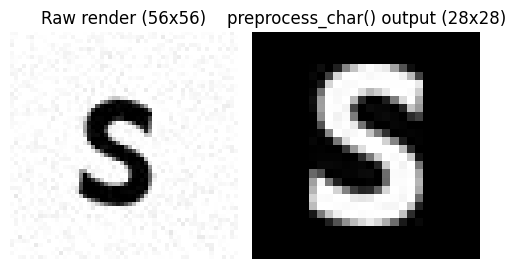

In [14]:
sample_raw = render_char("S", FONT_CANDIDATES[0], 36, rotation=-6, noise=0.03, seed=1)
sample_processed = preprocess_char(sample_raw).reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(5, 3))
axes[0].imshow(sample_raw, cmap="gray"); axes[0].set_title("Raw render (56x56)"); axes[0].axis("off")
axes[1].imshow(sample_processed, cmap="gray"); axes[1].set_title("preprocess_char() output (28x28)"); axes[1].axis("off")
plt.tight_layout()
plt.show()

Now generate the full labeled dataset: 36 classes (`0-9`, `A-Z`), ~220 renders
each with random font/size/rotation/noise for variety. Every label is free
and correct because we drew the text ourselves -- same trick as Part A.

In [15]:
import string as _string
CLASSES = list(_string.digits) + list(_string.ascii_uppercase)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

def build_dataset(samples_per_class=220, seed=42):
    rng = random.Random(seed)
    np.random.seed(seed)
    X, y = [], []
    for ch in CLASSES:
        for i in range(samples_per_class):
            font_path = rng.choice(FONT_CANDIDATES)
            raw = render_char(ch, font_path, rng.randint(30, 40), rng.uniform(-8, 8),
                               rng.choice([0.0, 0.0, 0.03, 0.06]), seed=hash((ch, i)) & 0xFFFF)
            X.append(preprocess_char(raw))
            y.append(CLASS_TO_IDX[ch])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

X, y = build_dataset()
print("Dataset:", X.shape, y.shape, "  (", len(CLASSES), "classes,", X.shape[0] // len(CLASSES), "samples/class )")

Dataset: (7920, 784) (7920,)   ( 36 classes, 220 samples/class )


### Part E — Class balance check

min=220 (0)  max=220 (0)  mean=220.0  std=0.00


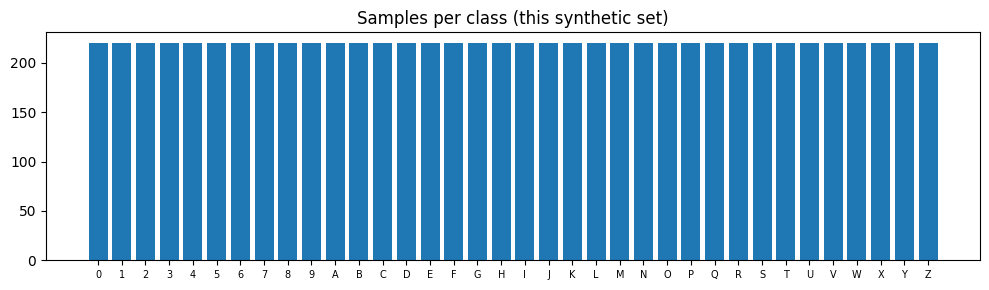

Balanced by construction -- the OPPOSITE of real EMNIST ByClass, which is
naturally imbalanced (digits >> letters, Q/X are rare). Part J's real model
has to make an explicit decision about that; this dataset never had to.


In [16]:
import numpy as np
counts = np.bincount(y, minlength=len(CLASSES))
print(f"min={counts.min()} ({CLASSES[int(counts.argmin())]})  max={counts.max()} ({CLASSES[int(counts.argmax())]})  "
      f"mean={counts.mean():.1f}  std={counts.std():.2f}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(CLASSES, counts)
ax.set_title("Samples per class (this synthetic set)")
plt.xticks(fontsize=7)
plt.tight_layout()
plt.show()

print("Balanced by construction -- the OPPOSITE of real EMNIST ByClass, which is")
print("naturally imbalanced (digits >> letters, Q/X are rare). Part J's real model")
print("has to make an explicit decision about that; this dataset never had to.")

Train / validation / test split
The data gets divided three ways:
* 70% for training
* 15% for validation (checked during training to catch problems early)
* 15% for test (touched only once, at the very end, for an honest final number).

Splitting it this way means the model's real performance gets measured on examples it never trained on, instead of reporting a number that's really just memorization.

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)
print(f"Train: {len(y_train)}   Val: {len(y_val)}   Test: {len(y_test)}")

Train: 5544   Val: 1188   Test: 1188


## Part F — Train the classifier, watch it learn

A small MLP stands in for the CNN locally (see the scope note in Part E --
GPU + real EMNIST is Part J). Training and validation accuracy are tracked
every epoch against the split above, and the test set is touched exactly
once, at the end.

In [18]:
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings("ignore")

clf = MLPClassifier(hidden_layer_sizes=(256, 128), activation="relu", alpha=1e-4,
                     batch_size=128, learning_rate_init=1e-3, random_state=42)
classes_arr = np.arange(len(CLASSES))
history = {"epoch": [], "train_acc": [], "val_acc": []}
print("Training...")

Training...


In [19]:
N_EPOCHS = 25
for epoch in range(1, N_EPOCHS + 1):
    if epoch == 1:
        clf.partial_fit(X_train, y_train, classes=classes_arr)
    else:
        clf.partial_fit(X_train, y_train)
    train_acc, val_acc = clf.score(X_train, y_train), clf.score(X_val, y_val)
    history["epoch"].append(epoch); history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:2d}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}")

epoch  1  train_acc=0.9724  val_acc=0.9646
epoch  5  train_acc=1.0000  val_acc=1.0000
epoch 10  train_acc=1.0000  val_acc=1.0000
epoch 15  train_acc=1.0000  val_acc=1.0000
epoch 20  train_acc=1.0000  val_acc=1.0000
epoch 25  train_acc=1.0000  val_acc=1.0000


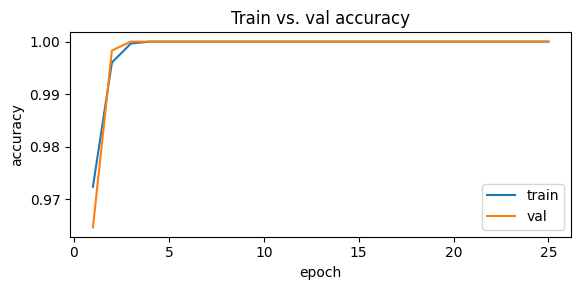

In [20]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(history["epoch"], history["train_acc"], label="train")
ax.plot(history["epoch"], history["val_acc"], label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.legend(); ax.set_title("Train vs. val accuracy")
plt.tight_layout()
plt.show()

#TEST

In [21]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
print(f"TEST  accuracy={test_acc:.4f}  macro_precision={prec:.4f}  macro_recall={rec:.4f}  macro_f1={f1:.4f}")

TEST  accuracy=1.0000  macro_precision=1.0000  macro_recall=1.0000  macro_f1=1.0000


In [22]:
print("What these mean:")
print(f"- Accuracy ({test_acc:.1%}): percent of individual CHARACTER images labeled correctly.")
print(f"- Macro precision ({prec:.1%}): of the times the model predicted a character, how often right -- equal weight per class.")
print(f"- Macro recall ({rec:.1%}): of all times a character actually appeared, how often caught -- equal weight per class.")
print(f"- Macro F1 ({f1:.1%}): balance of precision and recall.")
print()
print("Different costs: a LOW-PRECISION miss slips through to billing (a false charge).")
print("A LOW-RECALL miss shows up as low confidence, which the routing policy (Part G) can catch.")

What these mean:
- Accuracy (100.0%): percent of individual CHARACTER images labeled correctly.
- Macro precision (100.0%): of the times the model predicted a character, how often right -- equal weight per class.
- Macro recall (100.0%): of all times a character actually appeared, how often caught -- equal weight per class.
- Macro F1 (100.0%): balance of precision and recall.

Different costs: a LOW-PRECISION miss slips through to billing (a false charge).
A LOW-RECALL miss shows up as low confidence, which the routing policy (Part G) can catch.


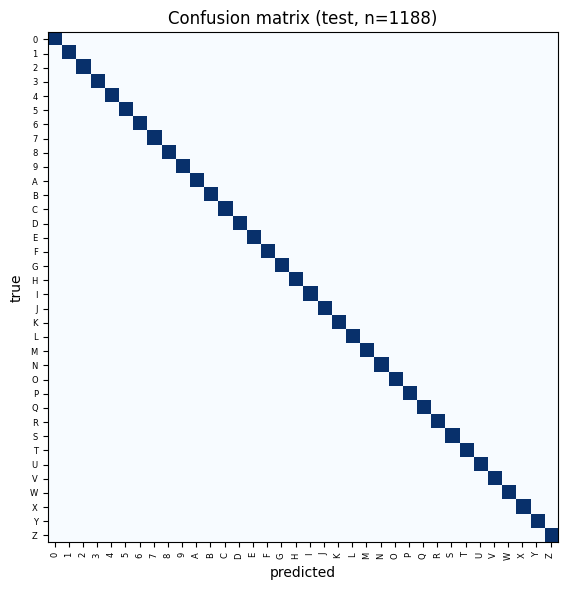

No confusions this run (test set classified perfectly) -- expected on this closed-loop
synthetic sanity check (small font pool). Re-check this cell against Part I's real EMNIST results.


In [23]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, fontsize=6, rotation=90)
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES, fontsize=6)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"Confusion matrix (test, n={len(y_test)})")
plt.tight_layout()
plt.show()

pairs = sorted(((cm[i, j], CLASSES[i], CLASSES[j]) for i in range(len(CLASSES)) for j in range(len(CLASSES)) if i != j and cm[i, j] > 0), reverse=True)
if not pairs:
    print("No confusions this run (test set classified perfectly) -- expected on this closed-loop")
    print("synthetic sanity check (small font pool). Re-check this cell against Part I's real EMNIST results.")
else:
    for count, a, b in pairs[:10]:
        kind = "digit-digit" if a.isdigit() and b.isdigit() else "letter-letter" if a.isalpha() and b.isalpha() else "digit-letter (visually similar glyph)"
        print(f"  {a} -> {b}: {count}x ({kind}). A plate with \'{a}\' could get billed as \'{b}\' -- refund + support call, ~$8.50 per the brief.")

## Part G - Full plate pipeline

Reuses `make_plate()` (Part A) and `segment_characters()` (Part B) unchanged.
`read_plate()` below is the single function the live demo calls: image in,
recognized text + per-character confidence + routing decision out.

In [24]:
def read_plate(img, conf_threshold=0.70):
    boxes = segment_characters(img)
    arr = np.array(img.convert("L"))
    crops = [arr[obj[0].start:obj[0].stop, obj[1].start:obj[1].stop] for obj in boxes]
    if not crops:
        return "", [], "ROUTE_TO_HUMAN", boxes
    feats = np.stack([preprocess_char(c) for c in crops])
    probs = clf.predict_proba(feats)
    pred_idx = probs.argmax(axis=1)
    confidences = probs.max(axis=1)
    pred_text = "".join(CLASSES[i] for i in pred_idx)
    decision = "AUTO_ACCEPT" if confidences.min() >= conf_threshold else "ROUTE_TO_HUMAN"
    return pred_text, confidences.tolist(), decision, boxes

Generate one fresh plate (or point `demo_img` at a real
uploaded image at demo time -- see the note below) and run it through the
full pipeline, showing every stage: image, segmentation boxes, per-character
crops, and the final read.

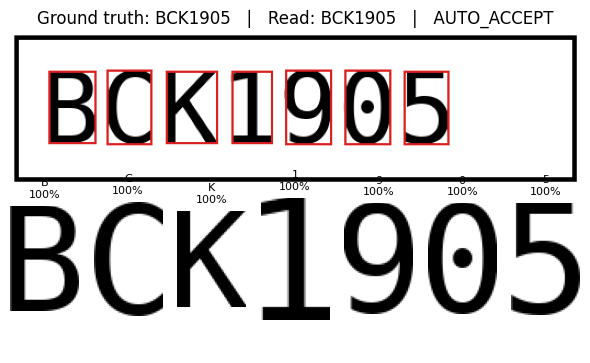

Correct: True


In [25]:
demo_img, demo_truth = make_plate(seed=123)
pred_text, confs, decision, boxes = read_plate(demo_img)

vis = demo_img.convert("RGB")
d = ImageDraw.Draw(vis)
for obj in boxes:
    d.rectangle([obj[1].start, obj[0].start, obj[1].stop, obj[0].stop], outline=(220, 30, 30), width=2)

fig, axes = plt.subplots(2, 1, figsize=(6, 4), gridspec_kw={"height_ratios": [2, 1]})
axes[0].imshow(vis); axes[0].axis("off")
axes[0].set_title(f"Ground truth: {demo_truth}   |   Read: {pred_text}   |   {decision}")

n = len(boxes)
for i, obj in enumerate(boxes):
    crop = np.array(demo_img.convert("L"))[obj[0].start:obj[0].stop, obj[1].start:obj[1].stop]
    ax_c = fig.add_subplot(2, n, n + i + 1)
    ax_c.imshow(crop, cmap="gray")
    conf_txt = f"{confs[i]:.0%}" if i < len(confs) else "?"
    ax_c.set_title(f"{pred_text[i] if i < len(pred_text) else '?'}\n{conf_txt}", fontsize=8)
    ax_c.axis("off")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"Correct: {pred_text == demo_truth}")

## Part H — Measuring accuracy across conditions

Batch-run the pipeline over synthetic plates at four quality levels, with
segmentation success and recognition accuracy tracked **separately** (per
brief §5) and every number attached to its condition.

In [26]:
import pandas as pd

CONDITIONS = [("clean", 0.0), ("light_noise", 0.06), ("moderate_noise", 0.12), ("heavy_noise", 0.20)]
N_PER_CONDITION = 60
rows = []
for cond_name, noise in CONDITIONS:
    for i in range(N_PER_CONDITION):
        seed = CONDITIONS.index((cond_name, noise)) * 10_000 + i
        img, text = make_plate(seed=seed, noise=noise)
        boxes_i = segment_characters(img)
        seg_success = len(boxes_i) == len(text)
        pred_text, confs, decision, _ = read_plate(img)
        char_acc = sum(p == t for p, t in zip(pred_text, text)) / len(text) if seg_success else None
        rows.append({"condition": cond_name, "ground_truth": text, "predicted": pred_text,
                      "seg_success": seg_success, "char_acc": char_acc,
                      "plate_correct": seg_success and pred_text == text,
                      "decision": decision, "min_confidence": min(confs) if confs else 0.0})
df = pd.DataFrame(rows)
print(f"Ran {len(df)} synthetic plates across {len(CONDITIONS)} conditions.")

Ran 240 synthetic plates across 4 conditions.


In [27]:
summary = df.groupby("condition").agg(
    n=("ground_truth", "count"),
    segmentation_success_rate=("seg_success", "mean"),
    plate_level_accuracy=("plate_correct", "mean"),
    char_level_accuracy=("char_acc", lambda s: s.dropna().mean()),
    pct_auto_accept=("decision", lambda s: (s == "AUTO_ACCEPT").mean()),
).round(4)
print(summary.to_string())

                 n  segmentation_success_rate  plate_level_accuracy  char_level_accuracy  pct_auto_accept
condition                                                                                                
clean           60                        1.0                   1.0                  1.0             1.00
heavy_noise     60                        1.0                   1.0                  1.0             0.95
light_noise     60                        1.0                   1.0                  1.0             1.00
moderate_noise  60                        1.0                   1.0                  1.0             1.00


In [28]:
auto = df[df["decision"] == "AUTO_ACCEPT"]
routed = df[df["decision"] == "ROUTE_TO_HUMAN"]
auto_correct_rate = auto["plate_correct"].mean() if len(auto) else float("nan")
print(f"Auto-accepted: {len(auto)} ({len(auto)/len(df):.1%}) -- of those, {auto_correct_rate:.1%} fully correct.")
print(f"Routed to human: {len(routed)} ({len(routed)/len(df):.1%}).")
print(f"Overall plate accuracy if EVERYTHING were auto-accepted (no routing): {df['plate_correct'].mean():.1%}")

Auto-accepted: 237 (98.8%) -- of those, 100.0% fully correct.
Routed to human: 3 (1.2%).
Overall plate accuracy if EVERYTHING were auto-accepted (no routing): 100.0%


Example plates with segmentation boxes and the read overlaid -- same visual style as Part B, now with the classifier's actual predictions.

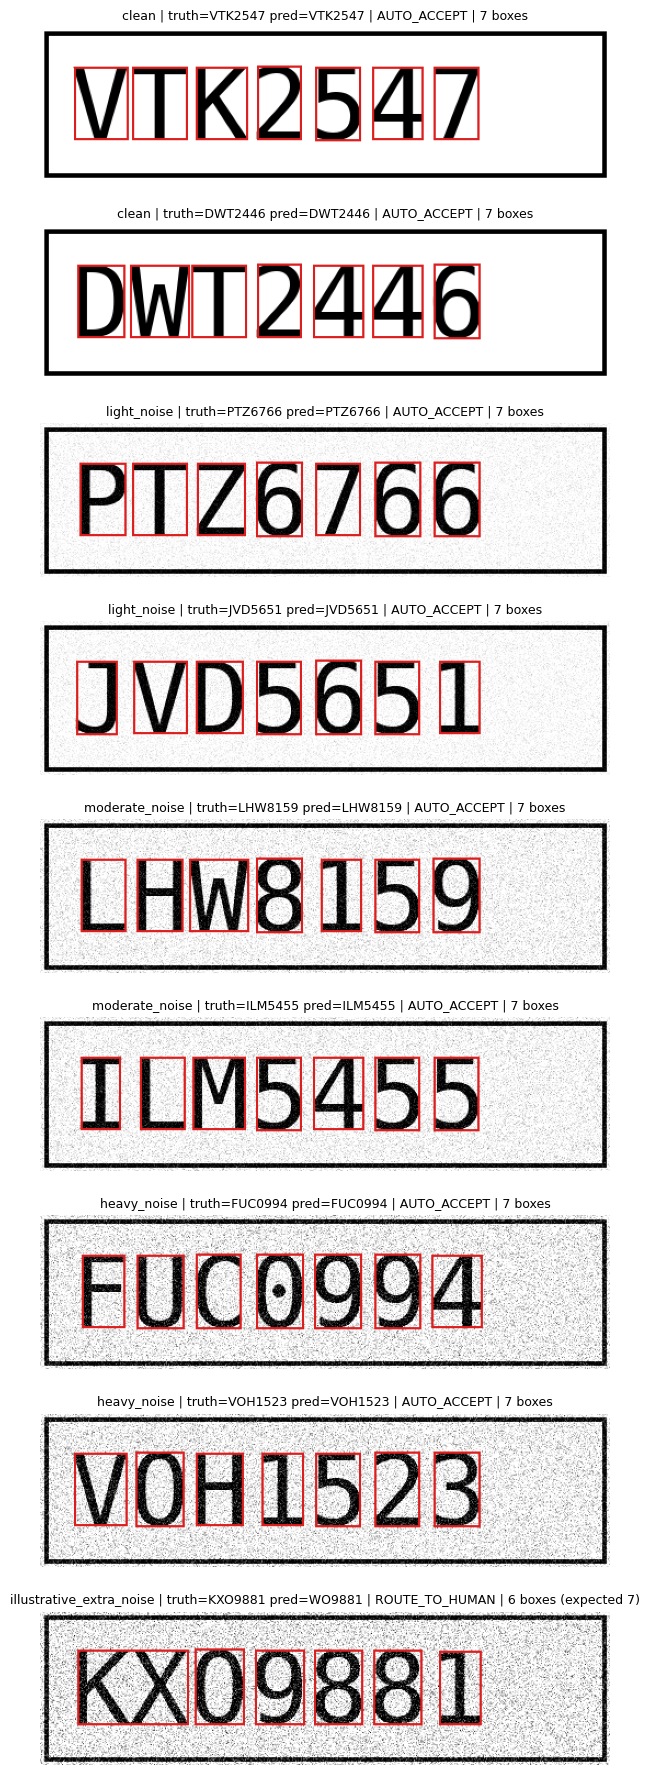

Per-character confidence for the routed example (last panel above, noise=0.25):
  W: 29.1%  <-- below threshold
  O: 94.6%
  9: 100.0%
  8: 100.0%
  8: 100.0%
  1: 99.7%


In [29]:
examples = []
for cond_name, noise in CONDITIONS:
    shown = 0
    for i in range(N_PER_CONDITION):
        if shown >= 2:
            break
        seed = CONDITIONS.index((cond_name, noise)) * 10_000 + i
        img, text = make_plate(seed=seed, noise=noise)
        pred_text, confs, decision, boxes_i = read_plate(img)
        examples.append((cond_name, img, text, pred_text, decision, boxes_i))
        shown += 1

found = None
found_confs = None
found_noise = None
for noise in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    for i in range(N_PER_CONDITION):
        seed = 500_000 + round(noise * 100) * 1000 + i
        img, text = make_plate(seed=seed, noise=noise)
        pred_text, confs, decision, boxes_i = read_plate(img)
        if decision == "ROUTE_TO_HUMAN":
            found = ("illustrative_extra_noise", img, text, pred_text, decision, boxes_i)
            found_confs = confs
            found_noise = noise
            break
    if found is not None:
        break

if found is not None:
    examples.append(found)

fig, axes = plt.subplots(len(examples), 1, figsize=(6, 2 * len(examples)))
for ax, (cond, img, text, pred, decision, boxes_i) in zip(axes, examples):
    vis = img.convert("RGB")
    d = ImageDraw.Draw(vis)
    for obj in boxes_i:
        d.rectangle([obj[1].start, obj[0].start, obj[1].stop, obj[0].stop], outline=(220, 30, 30), width=2)
    ax.imshow(vis)
    seg_note = f"{len(boxes_i)} boxes" + ("" if len(boxes_i) == len(text) else f" (expected {len(text)})")
    ax.set_title(f"{cond} | truth={text} pred={pred} | {decision} | {seg_note}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

if found is not None:
    print(f"Per-character confidence for the routed example (last panel above, noise={found_noise}):")
    for ch, c in zip(found[3], found_confs):
        flag = "  <-- below threshold" if c < 0.70 else ""
        print(f"  {ch}: {c:.1%}{flag}")
else:
    print("No routed example found even at elevated noise levels -- worth rerunning.")

## Part J — The real model: CNN on real EMNIST

This is where the pipeline moves from the synthetic sanity check above to the real thing — real handwritten characters, run through a CNN instead of the local MLP. Everything else, segment_characters(), preprocess_char(), and read_plate()'s structure, stays unchanged; only the classifier itself changes. Training needs a GPU and a live download of the EMNIST dataset, so this step runs in Colab.

Reminders from Part D, restated because they matter here too: EMNIST is transposed (.T fix) AND inverted (white-on-black — flip with 255 - arr before calling preprocess_char()), ByClass is not balanced, and expect lower accuracy than the synthetic numbers above — EMNIST is handwritten, plates are printed.

In [30]:
# Runs in Colab -- needs a GPU and a live EMNIST download.
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import datasets

torch.manual_seed(42)  # fixes the CNN's initial weights and the DataLoader's shuffle order, so a fresh run reproduces the same numbers

device = "cuda" if torch.cuda.is_available() else "cpu"
train_raw = datasets.EMNIST(root="./data", split="byclass", train=True, download=True)

def emnist_to_plate_convention(img):
    arr = np.array(img).T      # fix transpose bug (Part C/D)
    arr = 255 - arr            # EMNIST is white-on-black -> flip to match preprocess_char()'s convention
    return arr

class CharCNN(nn.Module):
    def __init__(self, n_classes=36):
        super().__init__()
        self.conv1, self.conv2 = nn.Conv2d(1, 32, 3, padding=1), nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1, self.fc2 = nn.Linear(64 * 7 * 7, 128), nn.Linear(128, n_classes)
        self.dropout = nn.Dropout(0.25)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(F.relu(self.fc1(x.flatten(1))))
        return self.fc2(x)

Filtering to the 36 characters we need, and normalizing them to match Part E

EMNIST's own label numbering already happens to put digits at 0–9 and uppercase letters at 10–35, in the same order as our CLASSES list — lowercase comes after that, at 36–61. So we can filter down to just what a plate would ever show by keeping label < 36, with no relabeling needed.

Full EMNIST ByClass has around 700,000 training images, and the classes aren't evenly represented. Instead of using all of it, we capped each class at a set number of samples (3,000 for training, 1,000 for test) — enough to train on real handwriting without turning this into a multi-hour job. Each kept image runs through emnist_to_plate_convention() (fixing the transpose and inverting the colors) and then preprocess_char(), the same normalization our synthetic characters went through, so the CNN sees data in a consistent format no matter where it came from.


In [31]:
import numpy as np

N_PER_CLASS_TRAIN = 3000  # cap per class -- keeps training tractable on a Colab GPU in our timeline
N_PER_CLASS_TEST = 1000

def build_real_dataset(raw_dataset, cap_per_class):
    by_class = {c: [] for c in range(36)}
    filled = 0
    for img, label in raw_dataset:
        if label < 36 and len(by_class[label]) < cap_per_class:
            arr = emnist_to_plate_convention(img)
            by_class[label].append(preprocess_char(arr))
            if len(by_class[label]) == cap_per_class:
                filled += 1
                if filled == 36:
                    break
    X, y = [], []
    for label, imgs in by_class.items():
        X.extend(imgs)
        y.extend([label] * len(imgs))
    return np.stack(X), np.array(y)

test_raw = datasets.EMNIST(root="./data", split="byclass", train=False, download=True)

X_train_real, y_train_real = build_real_dataset(train_raw, N_PER_CLASS_TRAIN)
X_test_real, y_test_real = build_real_dataset(test_raw, N_PER_CLASS_TEST)

print(f"Real training set: {X_train_real.shape[0]} images across {len(set(y_train_real))} classes")
print(f"Real test set: {X_test_real.shape[0]} images across {len(set(y_test_real))} classes")

Real training set: 106062 images across 36 classes
Real test set: 30582 images across 36 classes


Carving out a validation set from the real training data

We have real train and test sets now, but no validation set yet — the same gap Part E filled with a 70/15/15 split for the synthetic data. Here we split the real training set the same way: 85% stays for training, 15% is held back as validation, stratified so every character class stays proportionally represented in both pieces. The real EMNIST test set stays untouched — same rule as before, it only gets used once, at the very end, for the final reported numbers.

In [32]:
from sklearn.model_selection import train_test_split

X_tr_real, X_val_real, y_tr_real, y_val_real = train_test_split(
    X_train_real, y_train_real, test_size=0.15, stratify=y_train_real, random_state=42
)

print(f"Train: {X_tr_real.shape[0]} | Val: {X_val_real.shape[0]} | Test (untouched): {X_test_real.shape[0]}")

Train: 90152 | Val: 15910 | Test (untouched): 30582


Preparing the data for PyTorch, and weighting for class imbalance

PyTorch needs data as tensors, organized into small batches rather than one image at a time — that's how GPU training works efficiently. This step wraps the train, validation, and test arrays into that format. It also computes a weight per character class: since some letters have far fewer real examples than others, the loss function needs to penalize mistakes on rare classes more heavily, so the model doesn't just learn to guess the most common characters and ignore the rest. This is the imbalance-handling approach the team settled on earlier.

In [33]:
import torch
from torch.utils.data import TensorDataset, DataLoader

def to_tensor_dataset(X, y):
    X_t = torch.tensor(X, dtype=torch.float32).reshape(-1, 1, 28, 28)  # (N, 1, 28, 28) -- reshape flat 784 back into a 28x28 image + channel dim
    y_t = torch.tensor(y, dtype=torch.long)
    return TensorDataset(X_t, y_t)

train_ds = to_tensor_dataset(X_tr_real, y_tr_real)
val_ds = to_tensor_dataset(X_val_real, y_val_real)
test_ds = to_tensor_dataset(X_test_real, y_test_real)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

class_counts = np.bincount(y_tr_real, minlength=36)
class_weights = torch.tensor(class_counts.sum() / (36 * class_counts), dtype=torch.float32).to(device)

print(f"Batches per epoch: {len(train_loader)}")
print(f"Class weight range: {class_weights.min():.2f}x to {class_weights.max():.2f}x")

Batches per epoch: 705
Class weight range: 0.98x to 1.19x


Setting up the model, loss function, and optimizer

The CharCNN class was already defined earlier in Part J — this step actually creates a working instance of it, moves it onto the GPU (or CPU, if no GPU is available), sets up the loss function using the class weights just computed so rare characters count more, and creates the optimizer, which is what actually updates the model's internal numbers during training.

In [34]:
model = CharCNN(n_classes=36).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"Model on: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model on: cuda
Total parameters: 424,996


Training the CNN

Same idea as Part F: one epoch means one full pass through the training data. For each batch of images, the model makes a guess, we measure how wrong it was (the loss), and the optimizer nudges the model's internal numbers to be a little less wrong next time — that's the loss.backward() / optimizer.step() pair. After each epoch, we check accuracy on both the training data and the held-out validation data, same overfitting check as before: if training accuracy keeps climbing while validation accuracy stalls or drops, that's a sign the model is memorizing rather than learning.

In [35]:
N_EPOCHS = 15
history = {"epoch": [], "train_acc": [], "val_acc": []}

def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

    train_acc = evaluate(train_loader)
    val_acc = evaluate(val_loader)
    history["epoch"].append(epoch)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if epoch == 1 or epoch % 3 == 0:
        print(f"Epoch {epoch:2d} | train acc {train_acc:.1%} | val acc {val_acc:.1%}")

Epoch  1 | train acc 89.9% | val acc 89.4%
Epoch  3 | train acc 92.0% | val acc 90.9%
Epoch  6 | train acc 93.4% | val acc 91.9%
Epoch  9 | train acc 94.5% | val acc 92.5%
Epoch 12 | train acc 95.0% | val acc 92.5%
Epoch 15 | train acc 95.6% | val acc 92.5%


Train accuracy keeps climbing through epoch 15 (89.9% → 95.6%) while validation accuracy plateaus around 92.5% after epoch 9. This is a mild overfitting signal.

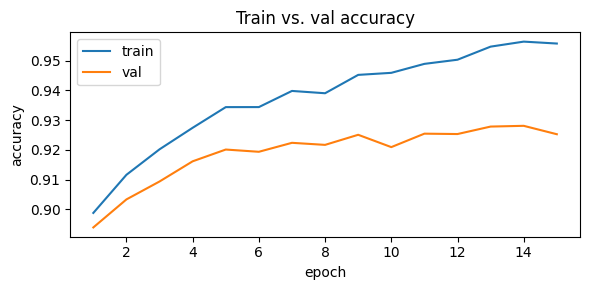

In [36]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(history["epoch"], history["train_acc"], label="train")
ax.plot(history["epoch"], history["val_acc"], label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.legend(); ax.set_title("Train vs. val accuracy")
plt.tight_layout()
plt.show()

Piece 1 — make the CNN answer questions the same way the MLP did. read_plate() calls clf.predict_proba(feats) to get a confidence score per character. The CNN doesn't have that method built in, so this wraps it to behave the same way.

In [37]:
class CNNClassifierWrapper:
    def __init__(self, model, device):
        self.model = model
        self.device = device
    def predict_proba(self, feats):
        x = torch.tensor(feats, dtype=torch.float32).reshape(-1, 1, 28, 28).to(self.device)
        self.model.eval()
        with torch.no_grad():
            probs = torch.softmax(self.model(x), dim=1)
        return probs.cpu().numpy()

cnn_clf = CNNClassifierWrapper(model, device)

Piece 2 — a version of read_plate() that can use either classifier. Rather than editing Part G's original function (and risking breaking anything upstream), this is the same logic with the classifier passed in as an argument instead of hardcoded:

In [38]:
def read_plate_with(img, classifier, conf_threshold=0.70):
    boxes = segment_characters(img)
    arr = np.array(img.convert("L"))
    crops = [arr[obj[0].start:obj[0].stop, obj[1].start:obj[1].stop] for obj in boxes]
    if not crops:
        return "", [], "ROUTE_TO_HUMAN", boxes
    feats = np.stack([preprocess_char(c) for c in crops])
    probs = classifier.predict_proba(feats)
    pred_idx = probs.argmax(axis=1)
    confidences = probs.max(axis=1)
    pred_text = "".join(CLASSES[i] for i in pred_idx)
    decision = "AUTO_ACCEPT" if confidences.min() >= conf_threshold else "ROUTE_TO_HUMAN"
    return pred_text, confidences.tolist(), decision, boxes

Testing the CNN on the same synthetic plates as the MLP

Same 4 conditions and same batch-run style as Part H, but using read_plate_with(img, cnn_clf) instead of the MLP's read_plate(img). This tells us how the CNN — trained only on real handwritten characters — handles printed, font-rendered plate text it's never seen the style of before. A meaningful drop here compared to the MLP's numbers isn't a bug; it's the real, honest domain-gap finding the brief wants documented.

In [39]:
rows_cnn = []
for cond_name, noise in CONDITIONS:
    for i in range(N_PER_CONDITION):
        seed = CONDITIONS.index((cond_name, noise)) * 10_000 + i
        img, text = make_plate(seed=seed, noise=noise)
        boxes_i = segment_characters(img)
        seg_success = len(boxes_i) == len(text)
        pred_text, confs, decision, _ = read_plate_with(img, cnn_clf)
        char_acc = sum(p == t for p, t in zip(pred_text, text)) / len(text) if seg_success else None
        rows_cnn.append({"condition": cond_name, "ground_truth": text, "predicted": pred_text,
                          "seg_success": seg_success, "char_acc": char_acc,
                          "plate_correct": seg_success and pred_text == text,
                          "decision": decision, "min_confidence": min(confs) if confs else 0.0})
df_cnn = pd.DataFrame(rows_cnn)

summary_cnn = df_cnn.groupby("condition").agg(
    n=("ground_truth", "count"),
    segmentation_success_rate=("seg_success", "mean"),
    plate_level_accuracy=("plate_correct", "mean"),
    char_level_accuracy=("char_acc", lambda s: s.dropna().mean()),
    pct_auto_accept=("decision", lambda s: (s == "AUTO_ACCEPT").mean()),
).round(4)
print(summary_cnn.to_string())

                 n  segmentation_success_rate  plate_level_accuracy  char_level_accuracy  pct_auto_accept
condition                                                                                                
clean           60                        1.0                0.3667               0.8667           0.4333
heavy_noise     60                        1.0                0.3667               0.8500           0.3667
light_noise     60                        1.0                0.4500               0.8905           0.4500
moderate_noise  60                        1.0                0.4667               0.9071           0.3333


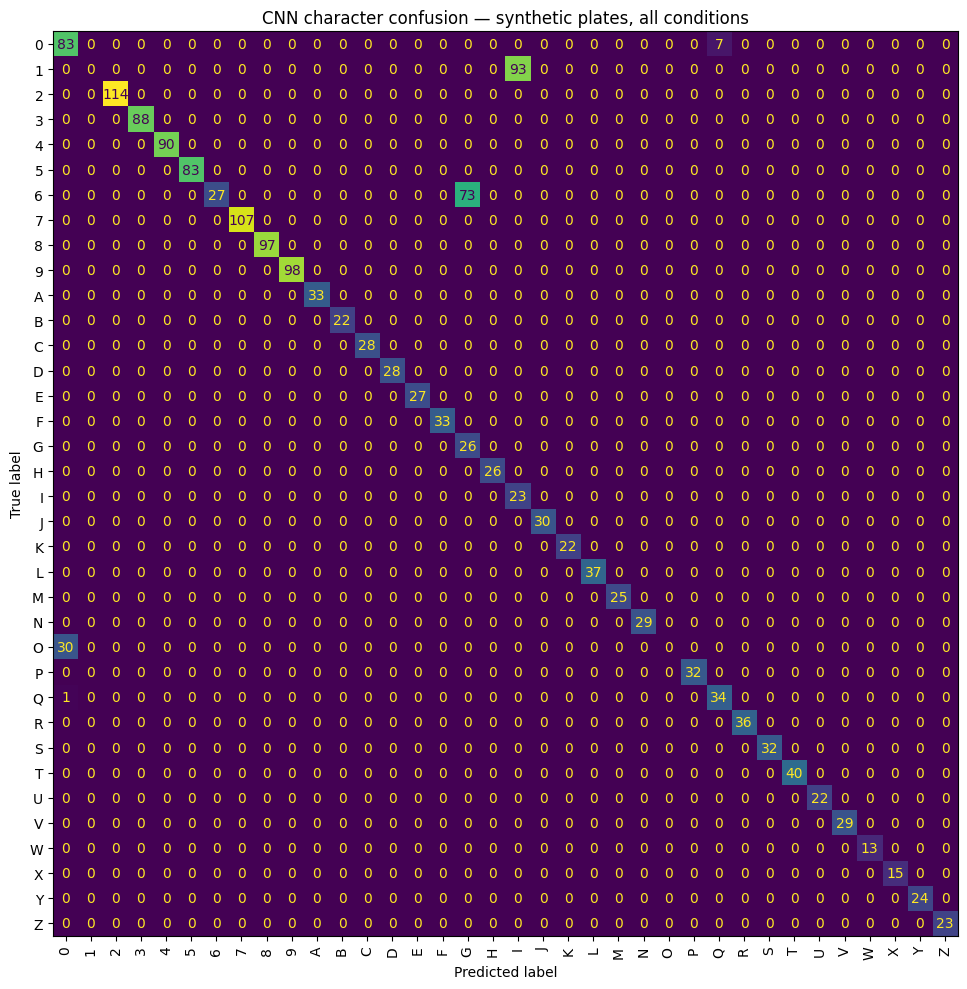

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

true_chars, pred_chars = [], []
for _, row in df_cnn.iterrows():
    if row["seg_success"] and len(row["predicted"]) == len(row["ground_truth"]):
        true_chars.extend(list(row["ground_truth"]))
        pred_chars.extend(list(row["predicted"]))

cm = confusion_matrix(true_chars, pred_chars, labels=CLASSES)

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, xticks_rotation=90, colorbar=False)
ax.set_title("CNN character confusion — synthetic plates, all conditions")
plt.tight_layout()
plt.show()

What these numbers mean

segmentation_success_rate stays at 1.0 across every condition — expected, since the CNN reuses the same segment_characters() step as the MLP, so this part isn't affected by which classifier reads the boxes.

char_level_accuracy sits around 84–91%: how often the CNN reads a single character correctly on printed plate text. That's noticeably lower than its 92%+ on real handwritten EMNIST, since printed, font-rendered text is a style it never trained on.

plate_level_accuracy drops much further, to roughly 37–47%: how often all 7 characters on a plate are correct. Even a mid-80s to low-90s per-character rate compounds down into a much lower plate-level rate, since a single wrong character fails the whole plate.

pct_auto_accept sits well below the MLP's rate — meaning the routing policy correctly picked up on the CNN being less confident on data outside its training domain, rather than confidently wrong.

Bottom line: the CNN is a strong real-handwriting recognizer, but a poor fit for printed plate text without more training on printed-style data. This is a proof of concept, not a deployment-ready system — neither model has been validated on real plate photos at the accuracy or scale Meridian would need. More time is needed, particularly to retrain the CNN on more varied, less filtered data.

In [41]:
from sklearn.metrics import precision_recall_fscore_support

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

test_acc_cnn = np.mean(np.array(all_preds) == np.array(all_true))
prec_cnn, rec_cnn, f1_cnn, _ = precision_recall_fscore_support(all_true, all_preds, average="macro", zero_division=0)

print(f"Real EMNIST test accuracy: {test_acc_cnn:.1%}")
print(f"Macro precision: {prec_cnn:.1%} | Macro recall: {rec_cnn:.1%} | Macro F1: {f1_cnn:.1%}")

Real EMNIST test accuracy: 92.2%
Macro precision: 92.7% | Macro recall: 92.8% | Macro F1: 92.5%


In [42]:
print("What these mean:")
print(f"- Accuracy ({test_acc_cnn:.1%}): percent of individual CHARACTER images labeled correctly -- real handwritten EMNIST characters this time, not synthetic.")
print(f"- Macro precision ({prec_cnn:.1%}): of the times the model predicted a character, how often right -- equal weight per class.")
print(f"- Macro recall ({rec_cnn:.1%}): of all times a character actually appeared, how often caught -- equal weight per class.")
print(f"- Macro F1 ({f1_cnn:.1%}): balance of precision and recall.")
print()
print("This is measured on real handwritten characters, the CNN's native domain. When this same model reads printed plate text instead (the synthetic-plate test above), accuracy drops sharply -- that gap is the handwritten-vs-printed domain difference the brief told us to expect, not a bug.")

What these mean:
- Accuracy (92.2%): percent of individual CHARACTER images labeled correctly -- real handwritten EMNIST characters this time, not synthetic.
- Macro precision (92.7%): of the times the model predicted a character, how often right -- equal weight per class.
- Macro recall (92.8%): of all times a character actually appeared, how often caught -- equal weight per class.
- Macro F1 (92.5%): balance of precision and recall.

This is measured on real handwritten characters, the CNN's native domain. When this same model reads printed plate text instead (the synthetic-plate test above), accuracy drops sharply -- that gap is the handwritten-vs-printed domain difference the brief told us to expect, not a bug.


Putting both models side by side

Everything above ran the MLP and the CNN through the exact same synthetic plates, separately. This puts their plate-level numbers next to each other in one table and one chart, so the difference is immediate instead of something you have to piece together from two separate results sections.

                MLP_char_acc  MLP_plate_acc  CNN_char_acc  CNN_plate_acc
condition                                                               
clean                    1.0            1.0        0.8667         0.3667
heavy_noise              1.0            1.0        0.8500         0.3667
light_noise              1.0            1.0        0.8905         0.4500
moderate_noise           1.0            1.0        0.9071         0.4667


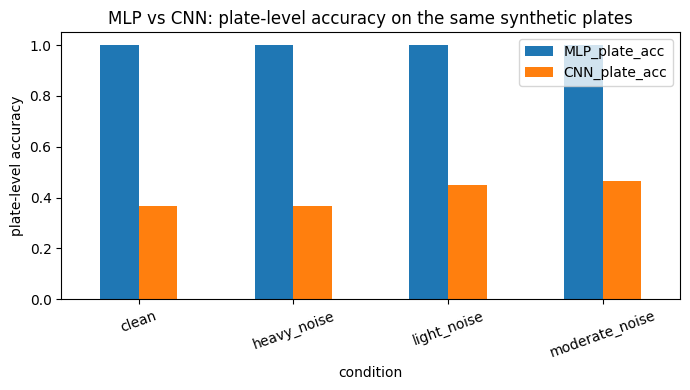

In [43]:
comparison = summary[["char_level_accuracy", "plate_level_accuracy"]].rename(
    columns={"char_level_accuracy": "MLP_char_acc", "plate_level_accuracy": "MLP_plate_acc"}
).join(
    summary_cnn[["char_level_accuracy", "plate_level_accuracy"]].rename(
        columns={"char_level_accuracy": "CNN_char_acc", "plate_level_accuracy": "CNN_plate_acc"}
    )
)
print(comparison.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
comparison[["MLP_plate_acc", "CNN_plate_acc"]].plot(kind="bar", ax=ax)
ax.set_ylabel("plate-level accuracy")
ax.set_title("MLP vs CNN: plate-level accuracy on the same synthetic plates")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##DEMO

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import os
folder = "/content/drive/MyDrive/FIU - Group 2 Summer /Machine Learning/Final Project /images"
print(os.listdir(folder))

['sample plate', 'cropsample.png', 'demo.png']


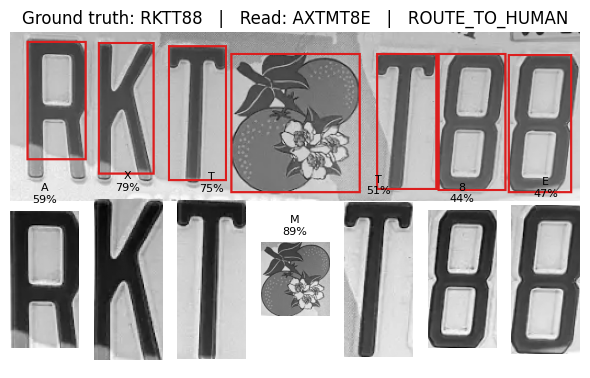

Correct: False


In [48]:
img_path = "/content/drive/MyDrive/FIU - Group 2 Summer /Machine Learning/Final Project /images/demo.png"
demo_img = Image.open(img_path).convert("L")
demo_truth = "RKTT88"  # read directly off the plate

pred_text, confs, decision, boxes = read_plate(demo_img)

vis = demo_img.convert("RGB")
d = ImageDraw.Draw(vis)
for obj in boxes:
    d.rectangle([obj[1].start, obj[0].start, obj[1].stop, obj[0].stop], outline=(220, 30, 30), width=2)

fig, axes = plt.subplots(2, 1, figsize=(6, 4), gridspec_kw={"height_ratios": [2, 1]})
axes[0].imshow(vis); axes[0].axis("off")
axes[0].set_title(f"Ground truth: {demo_truth}   |   Read: {pred_text}   |   {decision}")

n = len(boxes)
for i, obj in enumerate(boxes):
    crop = np.array(demo_img.convert("L"))[obj[0].start:obj[0].stop, obj[1].start:obj[1].stop]
    ax_c = fig.add_subplot(2, n, n + i + 1)
    ax_c.imshow(crop, cmap="gray")
    conf_txt = f"{confs[i]:.0%}" if i < len(confs) else "?"
    ax_c.set_title(f"{pred_text[i] if i < len(pred_text) else '?'}\n{conf_txt}", fontsize=8)
    ax_c.axis("off")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"Correct: {pred_text == demo_truth}")

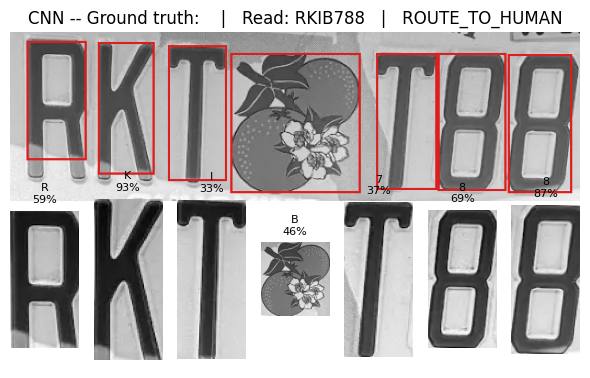

MLP read:  AXTMT8E   (correct: False)
CNN read:  RKIB788   (correct: False)


In [47]:
pred_text_cnn, confs_cnn, decision_cnn, boxes_cnn = read_plate_with(demo_img, cnn_clf)

vis_cnn = demo_img.convert("RGB")
d = ImageDraw.Draw(vis_cnn)
for obj in boxes_cnn:
    d.rectangle([obj[1].start, obj[0].start, obj[1].stop, obj[0].stop], outline=(220, 30, 30), width=2)

fig, axes = plt.subplots(2, 1, figsize=(6, 4), gridspec_kw={"height_ratios": [2, 1]})
axes[0].imshow(vis_cnn); axes[0].axis("off")
axes[0].set_title(f"CNN -- Ground truth: {demo_truth}   |   Read: {pred_text_cnn}   |   {decision_cnn}")

n = len(boxes_cnn)
for i, obj in enumerate(boxes_cnn):
    crop = np.array(demo_img.convert("L"))[obj[0].start:obj[0].stop, obj[1].start:obj[1].stop]
    ax_c = fig.add_subplot(2, n, n + i + 1)
    ax_c.imshow(crop, cmap="gray")
    conf_txt = f"{confs_cnn[i]:.0%}" if i < len(confs_cnn) else "?"
    ax_c.set_title(f"{pred_text_cnn[i] if i < len(pred_text_cnn) else '?'}\n{conf_txt}", fontsize=8)
    ax_c.axis("off")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"MLP read:  {pred_text}   (correct: {pred_text == demo_truth})")
print(f"CNN read:  {pred_text_cnn}   (correct: {pred_text_cnn == demo_truth})")